# Modelos Agrupacion Macrogrupos

In [1]:
import sys
import os
import importlib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))


import src.features.preprocessing_4classes as prep
importlib.reload(prep) 
df, X, y = prep.preprocessing()

df.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped_4
0,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False,other
1,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False,other
2,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False,other
3,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False,other
4,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False,other


In [2]:
from src.models.compare_models import compare_models

results = compare_models(X, y)

Entrenando Logistic Regression...
Entrenando Random Forest...
Entrenando Gradient Boosting...
Entrenando KNN...
Entrenando LightGBM...


In [21]:
import pandas as pd

summary = []

for model_name, result in results.items():
    report = result["report"]

    for clase, metrics in report.items():
        # saltar accuracy porque no es dict
        if clase == "accuracy":
            continue

        # solo filas que tengan precision/recall/f1
        if isinstance(metrics, dict):
            summary.append({
                "Modelo": model_name,
                "Clase": clase,
                "Precision": metrics.get("precision", None),
                "Recall": metrics.get("recall", None),
                "F1-score": metrics.get("f1-score", None),
                "Soporte": metrics.get("support", None)
            })

summary_df = pd.DataFrame(summary)

summary_df

,Modelo,Clase,Precision,Recall,F1-score,Soporte
0,Logistic Regression,acoustic,0.535430,0.544491,0.539923,10755.0
1,Logistic Regression,mainstream,0.587036,0.609792,0.598198,12847.0
2,Logistic Regression,other,0.669466,0.506829,0.576904,13839.0
3,Logistic Regression,urban,0.462045,0.599490,0.521869,9016.0
4,Logistic Regression,macro avg,0.563494,0.565150,0.559223,46457.0
5,Logistic Regression,weighted avg,0.575387,0.562004,0.563550,46457.0
6,Random Forest,acoustic,0.640233,0.622315,0.631147,10755.0
7,Random Forest,mainstream,0.592174,0.680859,0.633427,12847.0
8,Random Forest,other,0.812915,0.654021,0.724863,13839.0
9,Random Forest,urban,0.649832,0.727817,0.686617,9016.0


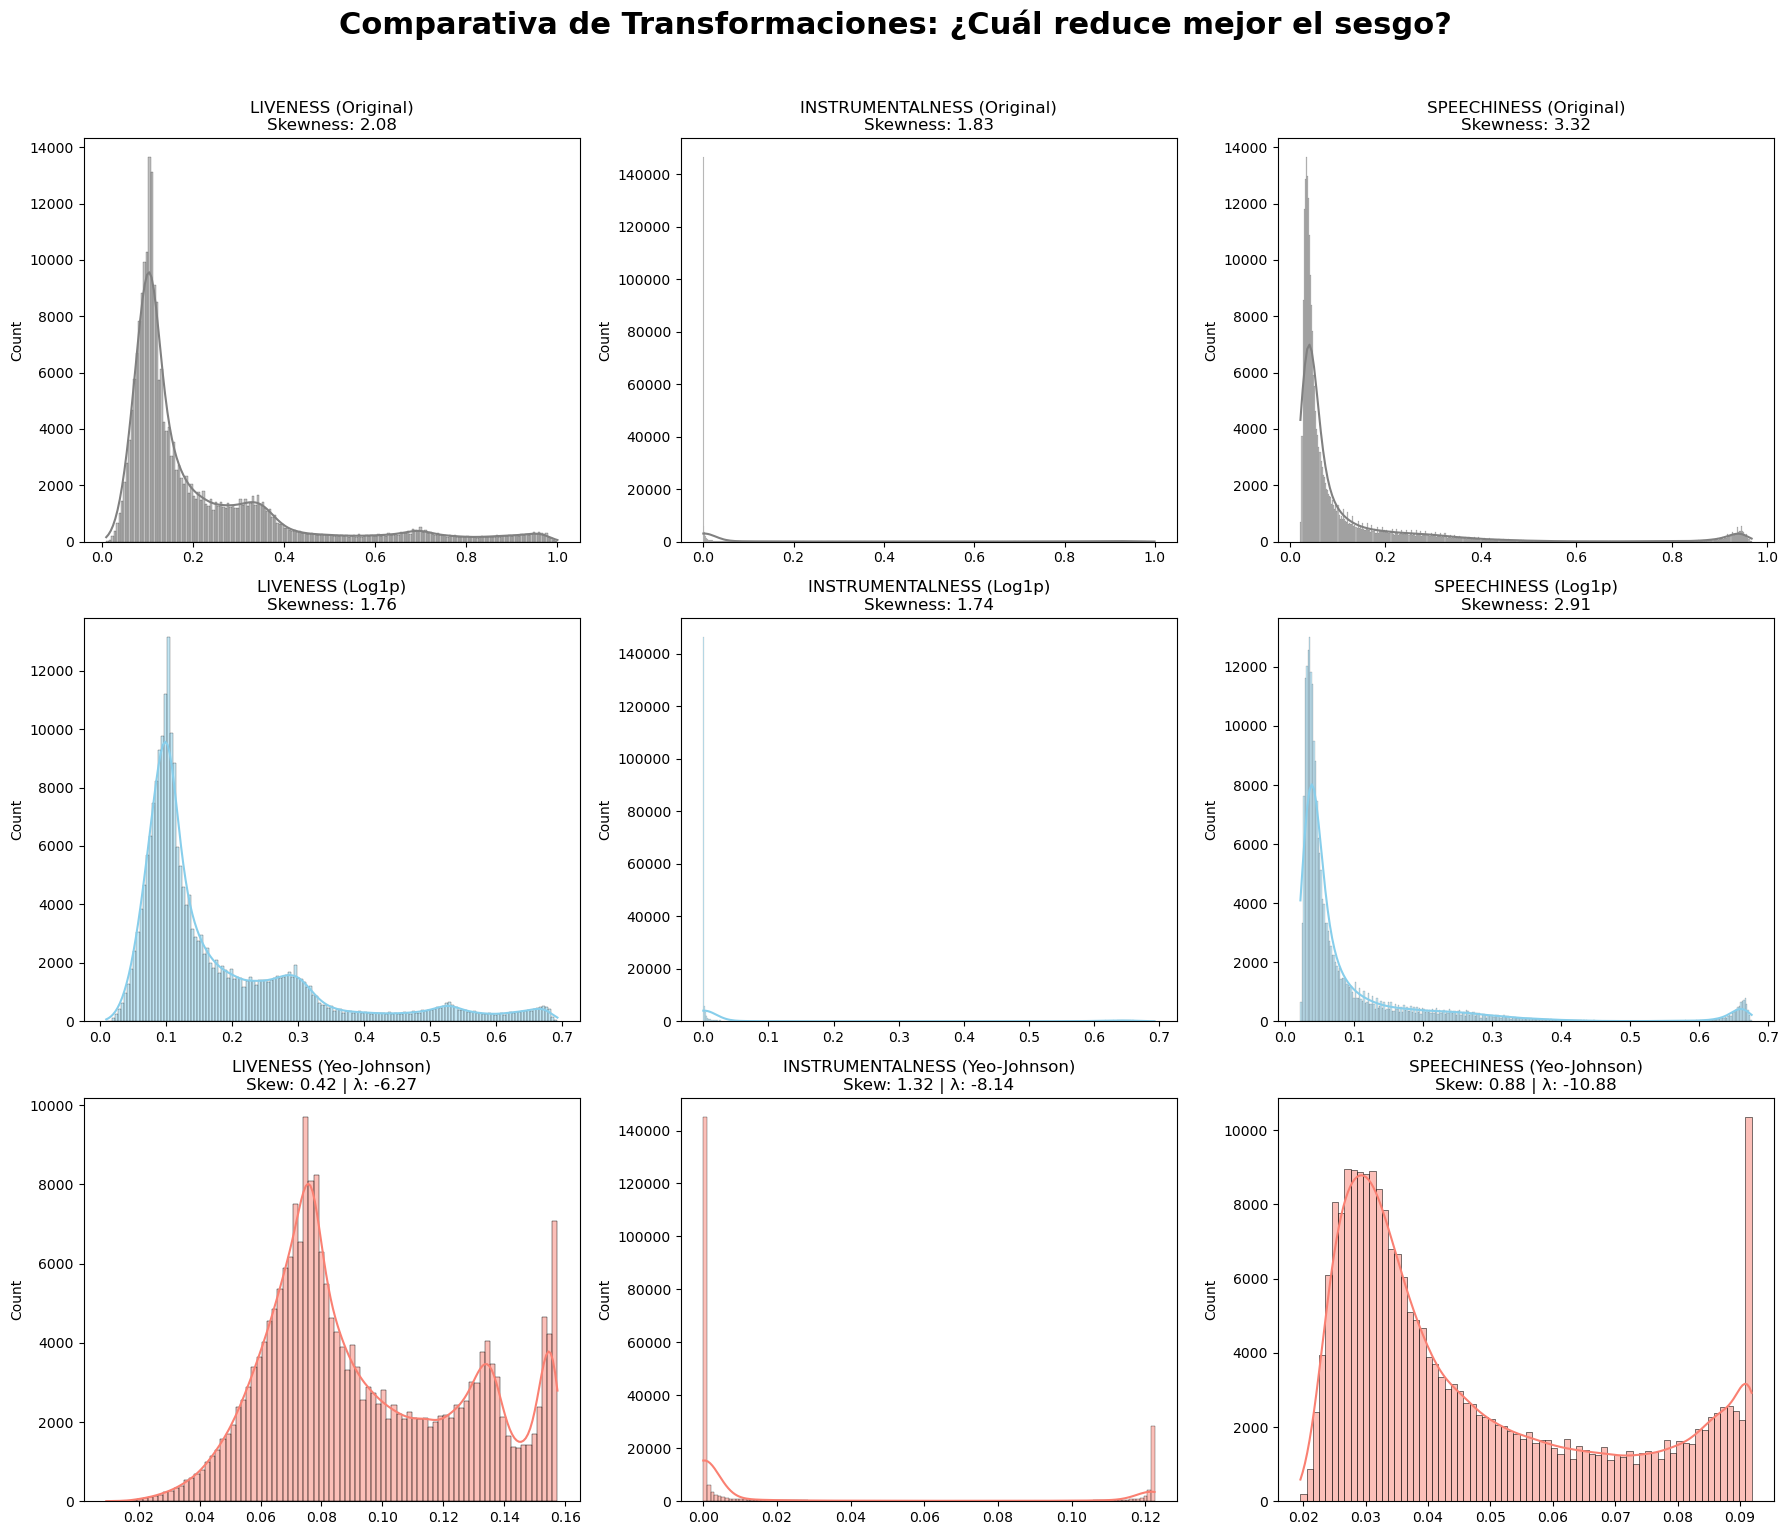

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def test_transformations(df):
    cols = ['liveness', 'instrumentalness', 'speechiness']
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    
    for i, col in enumerate(cols):

        raw_data = df[col].values
        
        sns.histplot(raw_data, kde=True, ax=axes[0, i], color='gray')
        axes[0, i].set_title(f'{col.upper()} (Original)\nSkewness: {stats.skew(raw_data):.2f}')

        log_data = np.log1p(raw_data)
        sns.histplot(log_data, kde=True, ax=axes[1, i], color='skyblue')
        axes[1, i].set_title(f'{col.upper()} (Log1p)\nSkewness: {stats.skew(log_data):.2f}')
        
        yj_data, lmbda = stats.yeojohnson(raw_data)
        sns.histplot(yj_data, kde=True, ax=axes[2, i], color='salmon')
        axes[2, i].set_title(f'{col.upper()} (Yeo-Johnson)\nSkew: {stats.skew(yj_data):.2f} | λ: {lmbda:.2f}')

    plt.suptitle('Comparativa de Transformaciones: ¿Cuál reduce mejor el sesgo?', 
                 fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

test_transformations(df)

In [5]:
from sklearn.preprocessing import PowerTransformer

def apply_yeo_johnson(df):

    cols_to_transform = ['liveness', 'instrumentalness', 'speechiness']

    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    
    # 3. Ajustamos y transformamos los datos
    df[cols_to_transform] = pt.fit_transform(df[cols_to_transform])
    
    print("Yeo-Johnson aplicado y datos estandarizados.")
    return df, pt

df_final, transformer = apply_yeo_johnson(df)

Yeo-Johnson aplicado y datos estandarizados.


In [6]:
from src.models.compare_main_models import compare_main_models 

y = df['genre_grouped_4']

columnas_a_eliminar = ['genre_grouped_4'] 
X = df.drop(columns=columnas_a_eliminar)

print(f"Forma de X: {X.shape}")
print(f"Clases en y: {y.unique()}")


results_trans = compare_main_models(X, y)

Forma de X: (232282, 15)
Clases en y: ['other' 'mainstream' 'acoustic' 'urban']
Entrenando Gradient Boosting...
Entrenando LightGBM...
Entrenando XGBoost...


In [7]:
import pandas as pd

summary = []

for model_name, result in results_trans.items():
    report = result["report"]
    summary.append({
        "Modelo": model_name,
        "Accuracy": report["accuracy"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

# Ordenar por lo que definiste como prioridad
summary_df = pd.DataFrame(summary).sort_values(
    by=["Macro Recall", "Macro F1"], 
    ascending=False
)

summary_df

,Modelo,Accuracy,Macro Recall,Macro F1,Weighted F1
1,LightGBM,0.686377,0.687989,0.686542,0.688434
2,XGBoost,0.678520,0.681528,0.678711,0.680580
0,Gradient Boosting,0.666595,0.668921,0.666123,0.668355


El modelo mejoro muy poco, la transformacion no era uno de los que afectaban el modelo 

In [8]:
%load_ext autoreload
%autoreload 2

df['energy_dance'] = df['energy'] * df['danceability']
df['mood'] = df['valence'] * df['energy']
    

df['loud_energy'] = df['loudness'] * df['energy']
df['loud_dance'] = df['loudness'] * df['danceability']
    
y = df['genre_grouped_4']

columnas_a_eliminar = ['genre_grouped_4'] 
X = df.drop(columns=columnas_a_eliminar)

In [9]:
%load_ext autoreload
%autoreload 2


print(f"Forma de X: {X.shape}")
print(f"Clases en y: {y.unique()}")

results_union = compare_main_models(X, y)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Forma de X: (232282, 19)
Clases en y: ['other' 'mainstream' 'acoustic' 'urban']
Entrenando Gradient Boosting...
Entrenando LightGBM...
Entrenando XGBoost...


In [10]:
import pandas as pd

summary = []

for model_name, result in results_union.items():
    report = result["report"]
    summary.append({
        "Modelo": model_name,
        "Accuracy": report["accuracy"],
        "Macro Recall": report["macro avg"]["recall"],
        "Macro F1": report["macro avg"]["f1-score"],
        "Weighted F1": report["weighted avg"]["f1-score"]
    })

# Ordenar por lo que definiste como prioridad
summary_df = pd.DataFrame(summary).sort_values(
    by=["Macro Recall", "Macro F1"], 
    ascending=False
)

summary_df

,Modelo,Accuracy,Macro Recall,Macro F1,Weighted F1
1,LightGBM,0.686592,0.687756,0.686604,0.688626
2,XGBoost,0.679596,0.682381,0.679644,0.681635
0,Gradient Boosting,0.669888,0.672437,0.669452,0.671612


El modelo mejoro muy poco, pero es algo que ayuda solo un poco a la prediccion asi que lo dejamos 

### Intento hiperparametros Gradient Boosting 

Se intento hacer algunos ajustes a los hiperparametros para ver que tan efectivo es el modelo, pero no se ven un resultado efectivo

In [11]:
from src.models.gradient_boosting_2 import train_gradient_boosting_model
report_gradient_2 = train_gradient_boosting_model(X, y)

print(report_gradient_2[1])

{'acoustic': {'precision': 0.6403903903903904, 'recall': 0.6344955834495584, 'f1-score': 0.6374293587408342, 'support': 10755.0}, 'mainstream': {'precision': 0.6102921287530431, 'recall': 0.7024986378142757, 'f1-score': 0.6531572281527049, 'support': 12847.0}, 'other': {'precision': 0.8129894058037771, 'recall': 0.6376905845798106, 'f1-score': 0.7147485219081559, 'support': 13839.0}, 'urban': {'precision': 0.6346721795629061, 'recall': 0.7150621118012422, 'f1-score': 0.67247314071138, 'support': 9016.0}, 'accuracy': 0.6698882837893105, 'macro avg': {'precision': 0.6745860261275292, 'recall': 0.6724367294112218, 'f1-score': 0.6694520623782687, 'support': 46457.0}, 'weighted avg': {'precision': 0.6823726539508929, 'recall': 0.6698882837893105, 'f1-score': 0.6716121638219481, 'support': 46457.0}}


### Probamos Modelo XGBoost 

Se prueba con un modelo XGBoost a ver si mejoran las metricas del modelo, se puede ver que el modelo mejora unas decimas. 

In [13]:
from src.models.XGBoost import train_xgboost_model
report_xgboost = train_gradient_boosting_model(X, y)


In [16]:
import pandas as pd

report_xgboost[1]


{'acoustic': {'precision': 0.6403903903903904,
  'recall': 0.6344955834495584,
  'f1-score': 0.6374293587408342,
  'support': 10755.0},
 'mainstream': {'precision': 0.6102921287530431,
  'recall': 0.7024986378142757,
  'f1-score': 0.6531572281527049,
  'support': 12847.0},
 'other': {'precision': 0.8129894058037771,
  'recall': 0.6376905845798106,
  'f1-score': 0.7147485219081559,
  'support': 13839.0},
 'urban': {'precision': 0.6346721795629061,
  'recall': 0.7150621118012422,
  'f1-score': 0.67247314071138,
  'support': 9016.0},
 'accuracy': 0.6698882837893105,
 'macro avg': {'precision': 0.6745860261275292,
  'recall': 0.6724367294112218,
  'f1-score': 0.6694520623782687,
  'support': 46457.0},
 'weighted avg': {'precision': 0.6823726539508929,
  'recall': 0.6698882837893105,
  'f1-score': 0.6716121638219481,
  'support': 46457.0}}

## Eliminar Variables 

Eliminamos las siguientes variables para confirmar si ayudan a la mejora del modelo 

In [17]:
cols_to_drop = ['duration_ms', 'genre_grouped_4']

X_eliminated = df.drop(columns=cols_to_drop, errors='ignore')
y = df['genre_grouped_4']

report_xgboost = train_gradient_boosting_model(X_eliminated, y)


In [18]:
report_xgboost[1]


{'acoustic': {'precision': 0.628916113345179,
  'recall': 0.6252905625290562,
  'f1-score': 0.6270980977247296,
  'support': 10755.0},
 'mainstream': {'precision': 0.6035759557008473,
  'recall': 0.7042110998676734,
  'f1-score': 0.650021554821095,
  'support': 12847.0},
 'other': {'precision': 0.8074504573170732,
  'recall': 0.6123997398655973,
  'f1-score': 0.6965276350934867,
  'support': 13839.0},
 'urban': {'precision': 0.6197100885300126,
  'recall': 0.7065217391304348,
  'f1-score': 0.6602746825602488,
  'support': 9016.0},
 'accuracy': 0.6590395419420109,
 'macro avg': {'precision': 0.6649131537232781,
  'recall': 0.6621057853481904,
  'f1-score': 0.6584804925498899,
  'support': 46457.0},
 'weighted avg': {'precision': 0.6733053391074274,
  'recall': 0.6590395419420109,
  'f1-score': 0.6605581384040734,
  'support': 46457.0}}

In [50]:
import pandas as pd

report = report_xgboost[1]

df_results = pd.DataFrame(report).transpose()

# reset index para que el nombre de clase sea columna
df_results = df_results.reset_index().rename(columns={'index': 'Clase'})

df_results

,Clase,precision,recall,f1-score,support
0,acoustic,0.623564,0.625941,0.624751,10755.00000
1,mainstream,0.598574,0.699307,0.645032,12847.00000
2,other,0.806371,0.603656,0.690442,13839.00000
3,urban,0.613195,0.699978,0.653719,9016.00000
4,accuracy,0.653960,0.653960,0.653960,0.65396
5,macro avg,0.660426,0.657221,0.653486,46457.00000
6,weighted avg,0.669097,0.653960,0.655550,46457.00000


In [19]:
from src.models.tune_best_model import tune_lightgbm

best_model, best_params, report, metrics = tune_lightgbm(X_eliminated, y, n_iter=20, cv=3)

Buscando mejores hiperparámetros (20 combinaciones, 3 folds)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores parámetros encontrados:
  classifier__colsample_bytree: 0.6227122864881435
  classifier__learning_rate: 0.04539154139343447
  classifier__max_depth: 7
  classifier__min_child_samples: 48
  classifier__n_estimators: 585
  classifier__num_leaves: 32
  classifier__reg_alpha: 0.15043915490838483
  classifier__reg_lambda: 1.0696809887549352
  classifier__subsample: 0.6129104315740864

Resultados en test:
  F1 Macro:    0.6756
  F1 Weighted: 0.6777
  Accuracy:    0.6760

Diagnóstico: OK — modelo bien calibrado


In [20]:

for clase, valores in report.items():
    if isinstance(valores, dict) and "recall" in valores:
        print(f"{clase}: {valores['recall']:.4f}")

acoustic: 0.6390
mainstream: 0.7237
other: 0.6422
urban: 0.7042
macro avg: 0.6773
weighted avg: 0.6760


### Conclusiones de los Modelos para esta Agrupacion 

En comparacion con el resto de modelos esta agrupacion muestra un mejor resultado en las metricas, esto se debe al menor desbalance que hay en comparacion entre las clases. El mejor modelo fue el de LightGBM con las siguientes metricas.

| Modelo   | Accuracy | Macro Recall | Macro F1 | Weighted F1 |
|----------|----------|--------------|----------|-------------|
| LightGBM | 0.685817 | 0.687393     | 0.685920 | 0.687886    |

